# Big Five Personality Inventory: Human vs LLM Comparison Analysis

This notebook performs comprehensive comparisons between human respondents and LLM-generated responses on a 50-item IPIP Big Five inventory.

# Imports

In [60]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix
from sklearn.covariance import EmpiricalCovariance
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore')

%matplotlib inline

# Configuration

In [76]:
# ============================================================================
# Configure paths here
# ============================================================================
model_path = "data/openai_gemini_responses_combined.csv"
human_path = "data/human_responses.csv" 
output_dir = Path("results/gemini_500")

# ============================================================================
# Configure labels here
# ============================================================================
MODEL_LABELS = {
    'gemini-2.5-flash-lite':         'G-2.5-Lite',
    'gemini-2.5-flash':              'G-2.5',
    'gemini-3-flash-preview':        'G-3',
    'gemini-3.1-flash-lite-preview': 'G-3.1-Lite',
}

# ============================================================================
# Configure plots here
# ============================================================================
COLORS = {
    'Human':                         '#F4A261',  # warm amber — reference baseline
    'gemini-2.5-flash-lite':         '#A8D8F5',  # sky blue     (lightest)
    'gemini-2.5-flash':              '#64AFEC',  # cornflower
    'gemini-3-flash-preview':        '#2E82D4',  # royal blue
    'gemini-3.1-flash-lite-preview': '#1256A8',  # deep blue    (darkest)
}
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor':    'black',
    'axes.labelcolor':   'black',
    'axes.titlecolor':   'black',
    'xtick.color':       'black',
    'ytick.color':       'black',
    'text.color':        'black',
    'grid.color':        'black',
    'grid.alpha':        0.3,
    'legend.facecolor':  'white',
    'legend.edgecolor':  'black',
    'legend.labelcolor': 'black',
})

# ============================================================================
# Configure trait here
# ============================================================================
# Define trait structure (which items belong to which trait)
TRAIT_STRUCTURE = {
    'Extraversion': [1, 6, 11, 16, 21, 26, 31, 36, 41, 46],
    'Agreeableness': [2, 7, 12, 17, 22, 27, 32, 37, 42, 47],
    'Conscientiousness': [3, 8, 13, 18, 23, 28, 33, 38, 43, 48],
    'Neuroticism': [4, 9, 14, 19, 24, 29, 34, 39, 44, 49],
    'Openness': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
}

# Items that need reverse scoring
REVERSE_ITEMS = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 39, 44, 46, 49]

TRAIT_ABBREV = {
    'Extraversion':      'EXT',
    'Agreeableness':     'AGR',
    'Conscientiousness': 'CSN',
    'Neuroticism':       'NEU',
    'Openness':          'OPN',
}

# Data Loading & Preprocessing

In [29]:
def _build_column_mapping():
    """Build mapping from EXT1-10, EST1-10, AGR1-10, CSN1-10, OPN1-10 -> item_1 to item_50"""
    column_mapping = {}
    item_num = 1
    for prefix in ['EXT', 'EST', 'AGR', 'CSN', 'OPN']:
        for i in range(1, 11):
            column_mapping[f'{prefix}{i}'] = f'item_{item_num}'
            item_num += 1
    return column_mapping


def load_human_LLM_data(human_path: str, llm_path: str) -> pd.DataFrame:
    """Load processed human and LLM data from separate CSV files."""
    column_mapping = _build_column_mapping()

    human_df = pd.read_csv(human_path)
    human_df = human_df.rename(columns=column_mapping)
    human_df['source'] = 'Human'
    human_df['respondent_id'] = range(1, len(human_df) + 1)

    # For now, the dataset of LLM reponse is following the columns structure of 'model' + col(human_df)
    llm_df = pd.read_csv(llm_path)
    llm_df = llm_df.rename(columns=column_mapping)
    # llm_df['source'] = 'LLM' 
    llm_df = llm_df.rename(columns={'model': 'source'})
    llm_df['respondent_id'] = range(1, len(llm_df) + 1)

    return pd.concat([human_df, llm_df], ignore_index=True)


def load_and_preprocess_data(human_path: str, llm_path: str) -> pd.DataFrame:
    """Load data and apply reverse scoring to specified items."""
    print('Caculating reverse items')
    df = load_human_LLM_data(human_path, llm_path)
    for item in REVERSE_ITEMS:
        col = f'item_{item}'
        if col in df.columns:
            df[col] = 6 - df[col]
    print('Reverse items finished')
    
    # Incase of future data amount grows
    print('Parsinng data types')
    item_cols = [f'item_{i}' for i in range(1, 51)]
    nan_counts = df[item_cols].isna().sum()
    total_nans = int(nan_counts.sum())

    if total_nans == 0:
        df[item_cols] = df[item_cols].astype('Int8')  # nullable int
        print("No NaNs found in item_1 to item_50. Converted to Int8.")
    else:
        print(f"Found {total_nans} NaN values across item_1 to item_50.")
        print("NaN count by column (non-zero only):")
        print(nan_counts[nan_counts > 0])
    return df


def compute_trait_scores(df: pd.DataFrame) -> pd.DataFrame:
    """Compute mean trait scores for each respondent"""
    trait_scores = df[['respondent_id', 'source']].copy()
    for trait_name, items in TRAIT_STRUCTURE.items():
        item_cols = [f'item_{i}' for i in items]
        trait_scores[trait_name] = df[item_cols].mean(axis=1)
    return trait_scores

- Concatenate all responses into a single DataFrame `df_all`
- Store each response source in the `source` column
- Convert item labels to standardized `item_i` columns (i = 1 to 50) to simplify downstream processing

In [33]:
df_all = load_and_preprocess_data(human_path, model_path)
print('Data loaded and preprocessed successfully')

Caculating reverse items
Reverse items finished
Parsinng data types
No NaNs found in item_1 to item_50. Converted to Int8.
Data loaded and preprocessed successfully


In [34]:
# Brief overview of df_all
print('\n===============================================\n')
print('Brief overview of df_all')
print("Shape:", df_all.shape)
print("Columns:", len(df_all.columns))
print("\nColumn names :", df_all.columns.tolist(), "...")

print("\nData types for each column:")
print(df_all[['respondent_id', 'source', 'item_1']].dtypes)

print("\nSource distribution:")
print(df_all["source"].value_counts())



Brief overview of df_all
Shape: (503653, 52)
Columns: 52

Column names : ['item_1', 'item_2', 'item_3', 'item_4', 'item_5', 'item_6', 'item_7', 'item_8', 'item_9', 'item_10', 'item_11', 'item_12', 'item_13', 'item_14', 'item_15', 'item_16', 'item_17', 'item_18', 'item_19', 'item_20', 'item_21', 'item_22', 'item_23', 'item_24', 'item_25', 'item_26', 'item_27', 'item_28', 'item_29', 'item_30', 'item_31', 'item_32', 'item_33', 'item_34', 'item_35', 'item_36', 'item_37', 'item_38', 'item_39', 'item_40', 'item_41', 'item_42', 'item_43', 'item_44', 'item_45', 'item_46', 'item_47', 'item_48', 'item_49', 'item_50', 'source', 'respondent_id'] ...

Data types for each column:
respondent_id    int64
source             str
item_1            Int8
dtype: object

Source distribution:
source
Human                            500703
gemini-2.5-flash-lite               500
gemini-2.5-flash                    500
gemini-3-flash-preview              500
gemini-3.1-flash-lite-preview       500
gpt-3.5-tur

- Caculate the traint scores for each reponses

In [40]:
trait_scores_all = compute_trait_scores(df_all)
trait_scores_all

,respondent_id,source,Extraversion,Agreeableness,Conscientiousness,Neuroticism,Openness
0,1,Human,3.4,2.9,3.5,3.3,3.5
1,2,Human,2.9,2.6,3.0,2.6,2.8
2,3,Human,3.3,2.5,2.9,2.8,2.7
3,4,Human,3.7,2.8,3.5,3.2,2.7
4,5,Human,3.0,3.4,3.5,3.3,3.0
...,...,...,...,...,...,...,...
503648,2946,gemini-3.1-flash-lite-preview,3.2,2.5,3.6,2.9,3.5
503649,2947,gemini-3.1-flash-lite-preview,3.4,2.8,3.5,3.0,3.3
503650,2948,gemini-3.1-flash-lite-preview,3.5,2.9,3.4,3.0,3.2
503651,2949,gemini-3.1-flash-lite-preview,3.3,2.6,3.4,3.1,3.2


# Utility Functions for Analysis

In [32]:
def cohen_d(x, y):
    """Calculate Cohen's d effect size"""
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 +
                                                  (ny-1)*np.std(y, ddof=1)**2) / dof)

def cronbach_alpha(items):
    """Calculate Cronbach's alpha reliability"""
    items = items.dropna()
    item_count = items.shape[1]
    variance_sum = items.var(axis=0, ddof=1).sum()
    total_var = items.sum(axis=1).var(ddof=1)
    return (item_count / (item_count - 1)) * (1 - variance_sum / total_var)

def wasserstein_distance(x, y):
    """Calculate 1D Wasserstein distance"""
    x_sorted = np.sort(x)
    y_sorted = np.sort(y)
    n = max(len(x), len(y))
    x_interp = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(x)), x_sorted)
    y_interp = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(y)), y_sorted)
    return np.mean(np.abs(x_interp - y_interp))

def jensen_shannon_divergence(p, q):
    """Calculate Jensen-Shannon divergence"""
    p = np.asarray(p)
    q = np.asarray(q)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)

    def kl_div(x, y):
        return np.sum(np.where(x != 0, x * np.log(x / y), 0))

    return 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)

def mahalanobis_distance(x, y, cov):
    """Calculate Mahalanobis distance between two vectors"""
    diff = x - y
    try:
        inv_cov = np.linalg.inv(cov)
        return np.sqrt(diff @ inv_cov @ diff.T)
    except:
        return np.nan

# Analysis Table 2: Trait-Level Mean Comparisons

In [65]:
"""Compare trait-level means between human and LLM responses"""
traits = list(TRAIT_STRUCTURE.keys())
results = dict()
llm_list = ['gemini-2.5-flash-lite', 'gemini-2.5-flash', 'gemini-3-flash-preview', 'gemini-3.1-flash-lite-preview']

rows = []
for trait in traits:
    human_vals = trait_scores_all[trait_scores_all['source'] == 'Human'][trait].values
    h_mean, h_sd = human_vals.mean(), human_vals.std()

    for llm in llm_list:
        llm_vals = trait_scores_all[trait_scores_all['source'] == llm][trait].values
        t_stat, p_val = stats.ttest_ind(llm_vals, human_vals)
        d = cohen_d(llm_vals, human_vals)
        rows.append({
            'Trait':    trait,
            'Model':    llm,
            'H_Mean':   h_mean,
            'H_SD':     h_sd,
            'L_Mean':   llm_vals.mean(),
            'L_SD':     llm_vals.std(),
            'Delta':    llm_vals.mean() - h_mean,
            't':        t_stat,
            'p':        p_val,
            'd':        d,
        })

df_table2 = pd.DataFrame(rows)
df_table2.head(10)

,Trait,Model,H_Mean,H_SD,L_Mean,L_SD,Delta,t,p,d
0,Extraversion,gemini-2.5-flash-lite,3.148293,0.407066,3.2380,0.168561,0.089707,4.927330,8.338728e-07,0.220467
1,Extraversion,gemini-2.5-flash,3.148293,0.407066,3.3110,0.243840,0.162707,8.936140,4.043175e-19,0.399836
2,Extraversion,gemini-3-flash-preview,3.148293,0.407066,3.4984,0.169159,0.350107,19.230212,2.214524e-82,0.860431
3,Extraversion,gemini-3.1-flash-lite-preview,3.148293,0.407066,3.3996,0.100499,0.251307,13.804233,2.447539e-43,0.617652
4,Agreeableness,gemini-2.5-flash-lite,2.888990,0.368798,3.0042,0.090436,0.115210,6.985128,2.849488e-12,0.312540
5,Agreeableness,gemini-2.5-flash,2.888990,0.368798,2.6908,0.248675,-0.198190,-12.013752,3.040643e-33,-0.537540
6,Agreeableness,gemini-3-flash-preview,2.888990,0.368798,2.7066,0.164410,-0.182390,-11.057406,2.033868e-28,-0.494749
7,Agreeableness,gemini-3.1-flash-lite-preview,2.888990,0.368798,2.8028,0.111791,-0.086190,-5.225542,1.737146e-07,-0.233810
8,Conscientiousness,gemini-2.5-flash-lite,3.244761,0.362971,3.2824,0.164513,0.037639,2.318503,2.042239e-02,0.103738
9,Conscientiousness,gemini-2.5-flash,3.244761,0.362971,3.3210,0.183429,0.076239,4.696077,2.652755e-06,0.210120


In [109]:
def fmt_p(p):
    if p < .001: return '< .001'
    if p < .01:  return f'{p:.3f}'
    return f'{p:.2f}'

col_human = [('Human', 'M (SD)')]
col_llms  = [
    (MODEL_LABELS[llm], stat)
    for llm in llm_list
    for stat in ['M (SD)', 't', 'd', 'p']
]
columns = pd.MultiIndex.from_tuples(col_human + col_llms)

table_data = {}

for trait in traits:
    sub = df_table2[df_table2['Trait'] == trait]
    h   = sub.iloc[0]
    row = {('Human', 'M (SD)'): f"{h['H_Mean']:.2f} ({h['H_SD']:.2f})"}

    for llm in llm_list:
        r   = sub[sub['Model'] == llm].iloc[0]
        lbl = MODEL_LABELS[llm]
        row[(lbl, 'M (SD)')] = f"{r['L_Mean']:.2f} ({r['L_SD']:.2f}) {r['Delta']:+.2f}"
        row[(lbl, 't')]      = f"{r['t']:+.2f}"
        row[(lbl, 'd')]      = f"{r['d']:+.2f}"
        row[(lbl, 'p')]      = fmt_p(r['p'])

    table_data[trait] = row

table_df = (
    pd.DataFrame(table_data)
      .T
      .rename_axis('Trait')
      .reindex(columns=columns)
)
table_df.to_csv(output_dir / 'table2_trait_means.csv')

In [110]:
table_df

Human         G-2.5-Lite                         \
                        M (SD)             M (SD)       t      d       p   
Trait                                                                      
Extraversion       3.15 (0.41)  3.24 (0.17) +0.09   +4.93  +0.22  < .001   
Agreeableness      2.89 (0.37)  3.00 (0.09) +0.12   +6.99  +0.31  < .001   
Conscientiousness  3.24 (0.36)  3.28 (0.16) +0.04   +2.32  +0.10    0.02   
Neuroticism        3.00 (0.33)  3.00 (0.11) -0.01   -0.45  -0.02    0.65   
Openness           3.03 (0.40)  3.29 (0.22) +0.26  +14.36  +0.64  < .001   

                               G-2.5                         \
                              M (SD)       t      d       p   
Trait                                                         
Extraversion       3.31 (0.24) +0.16   +8.94  +0.40  < .001   
Agreeableness      2.69 (0.25) -0.20  -12.01  -0.54  < .001   
Conscientiousness  3.32 (0.18) +0.08   +4.70  +0.21  < .001   
Neuroticism        2.92 (0.26) -0.08   -5.56  -0.25  < .001   
Openness           3.28 (0.23) +0.25  +14.18  +0.63  < .001   

                                 G-3                         \
                              M (SD)       t      d       p   
Trait                                                         
Extraversion       3.50 (0.17) +0.35  +19.23  +0.86  < .001   
Agreeableness      2.71 (0.16) -0.18  -11.06  -0.49  < .001   
Conscientiousness  3.41 (0.16) +0.17  +10.24  +0.46  < .001   
Neuroticism        2.63 (0.20) -0.37  -24.74  -1.11  < .001   
Openness           3.42 (0.17) +0.39  +21.96  +0.98  < .001   

                          G-3.1-Lite                         
                              M (SD)       t      d       p  
Trait                                                        
Extraversion       3.40 (0.10) +0.25  +13.80  +0.62  < .001  
Agreeableness      2.80 (0.11) -0.09   -5.23  -0.23  < .001  
Conscientiousness  3.40 (0.11) +0.16   +9.83  +0.44  < .001  
Neuroticism        2.98 (0.09) -0.02   -1.61  -0.07    0.11  
Openness           3.29 (0.11) +0.26  +14.66  +0.66  < .001

## Rader

In [100]:
MARKERS = ['o', 's', '^', 'D', 'v', 'P']   # one per model, cycles if needed

angles = np.linspace(0, 2 * np.pi, len(traits), endpoint=False).tolist()
angles += angles[:1]

def close(vals):
    return np.concatenate([vals, [vals[0]]])

# ── Pre-compute stats ─────────────────────────────────────────────────────────

human_vals = trait_scores_all[trait_scores_all['source'] == 'Human'][traits]
h_mean = close(human_vals.mean().values)
h_sd   = close(human_vals.std().values)

llm_stats = {}
for llm in llm_list:
    sub = trait_scores_all[trait_scores_all['source'] == llm][traits]
    llm_stats[llm] = {
        'mean': close(sub.mean().values),
        'sd':   close(sub.std().values),
    }

# Adjuest the range
all_means = np.concatenate([h_mean] + [s['mean'] for s in llm_stats.values()])
all_sds   = np.concatenate([h_sd]   + [s['sd']   for s in llm_stats.values()])

y_min = max(1.0, round(((all_means - all_sds).min() - 0.25) * 4) / 4)
y_max = min(5.0, round(((all_means + all_sds).max()) * 4) / 4)

tick_step = 0.2 if (y_max - y_min) <= 2 else 1.0
yticks    = np.arange(y_min, y_max + 0.01, tick_step)

# ── Shared draw function ──────────────────────────────────────────────────────

def draw_radar(ax, with_bands: bool):
    
    abbrev_labels = [TRAIT_ABBREV[t] for t in traits]

    # Human
    if with_bands:
        ax.fill_between(angles, h_mean - h_sd, h_mean + h_sd,
                        color=COLORS['Human'], alpha=0.18,
                        label='Human ±1 SD' if with_bands else None)
    ax.plot(angles, h_mean, color=COLORS['Human'], linewidth=2.5,
            label='Human', zorder=3)
    ax.plot(angles, h_mean, 'o', color=COLORS['Human'],
            markersize=5, zorder=4)

    # LLMs
    for i, llm in enumerate(llm_list):
        color  = COLORS[llm]
        marker = MARKERS[i % len(MARKERS)]
        lm     = llm_stats[llm]['mean']
        ls     = llm_stats[llm]['sd']
        label  = MODEL_LABELS.get(llm, llm)

        if with_bands:
            ax.fill_between(angles, lm - ls, lm + ls,
                            color=color, alpha=0.15)

        ax.plot(angles, lm, color=color, linewidth=2,
                label=label, zorder=3)
        ax.plot(angles, lm, marker, color=color,
                markersize=5, zorder=4)

    # Axes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(abbrev_labels, fontsize=12)
    ax.tick_params(axis='x', pad=12)
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{v:.1f}' for v in yticks], fontsize=8)
    ax.set_rlabel_position(180 / len(traits))
    ax.grid(alpha=0.35)

    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.10),
        ncol=3,
        fontsize=9,
        framealpha=0.15,
    )


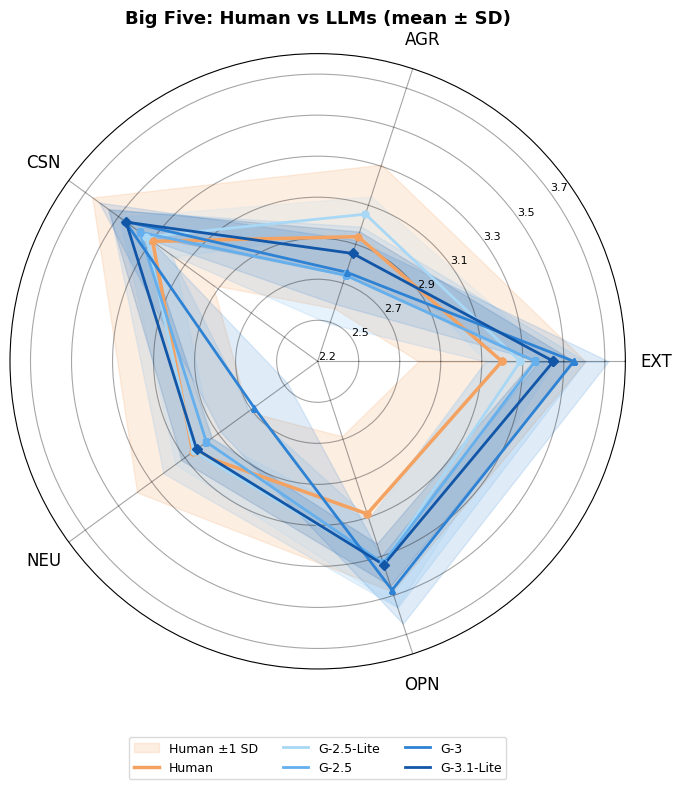

In [107]:
# ── Figure 1: with SD bands ───────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
draw_radar(ax, with_bands=True)
ax.set_title('Big Five: Human vs LLMs (mean ± SD)',
             fontsize=13, fontweight='bold', pad=22)
fig.tight_layout()
fig.savefig(os.path.join(output_dir, f'radar_with_bands.png'),
            dpi=300, bbox_inches='tight')
plt.show()

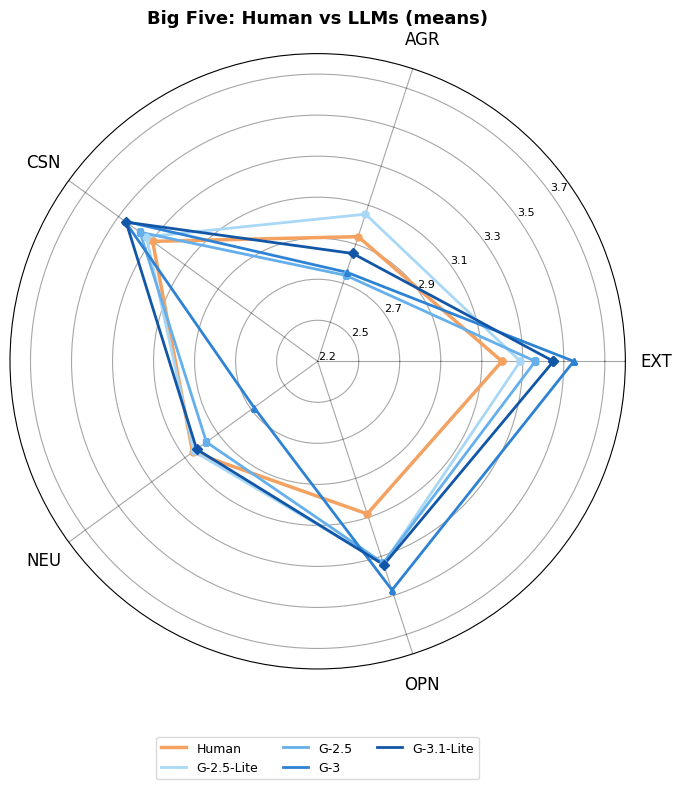

In [108]:
# ── Figure 2: means only ──────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
draw_radar(ax, with_bands=False)
ax.set_title('Big Five: Human vs LLMs (means)',
             fontsize=13, fontweight='bold', pad=22)
fig.tight_layout()
fig.savefig(os.path.join(output_dir, f'radar_means_only.png'),
            dpi=300, bbox_inches='tight')
plt.show()

In [134]:
# ── Pre-compute stats ─────────────────────────────────────────────────────────

human_vals = trait_scores_all[trait_scores_all['source'] == 'Human'][traits]
h_mean = close(human_vals.mean().values)
h_sd   = close(human_vals.std().values)

llm_stats = {}
for llm in llm_list:
    sub = trait_scores_all[trait_scores_all['source'] == llm][traits]
    llm_stats[llm] = {
        'mean': close(sub.mean().values),
        'sd':   close(sub.std().values),
    }

# Average mean and SD across all LLMs — used for the shared band
llm_mean_avg = np.mean([llm_stats[llm]['mean'] for llm in llm_list], axis=0)
llm_sd_avg   = np.mean([llm_stats[llm]['sd']   for llm in llm_list], axis=0)

# ── Shared draw function ──────────────────────────────────────────────────────

def draw_radar(ax, with_bands: bool):
    abbrev_labels = [TRAIT_ABBREV[t] for t in traits]

    if with_bands:
        # Human band
        ax.fill_between(angles, h_mean - h_sd, h_mean + h_sd,
                        color=COLORS['Human'], alpha=0.18, label='Human ±1 SD')
        # Single shared LLM band (avg SD across models)
        ax.fill_between(angles, llm_mean_avg - llm_sd_avg, llm_mean_avg + llm_sd_avg,
                        color=COLORS[llm_list[-1]], alpha=0.08, label='LLM avg ±1 SD')

    # Human mean
    ax.plot(angles, h_mean, color=COLORS['Human'], linewidth=2.5,
            label='Human', zorder=3)
    ax.plot(angles, h_mean, 'o', color=COLORS['Human'], markersize=5, zorder=4)

    # Individual LLM means
    for i, llm in enumerate(llm_list):
        color  = COLORS[llm]
        marker = MARKERS[i % len(MARKERS)]
        lm     = llm_stats[llm]['mean']
        ax.plot(angles, lm, color=color, linewidth=2,
                label=MODEL_LABELS.get(llm, llm), zorder=3)
        ax.plot(angles, lm, marker, color=color, markersize=5, zorder=4)

    # Axes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(abbrev_labels, fontsize=12)
    ax.tick_params(axis='x', pad=12)
    ax.set_ylim(1, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=9)
    ax.set_rlabel_position(180 / len(traits))
    ax.grid(alpha=0.35)
    ax.legend(
        loc='upper center', bbox_to_anchor=(0.5, -0.10),
        ncol=3, fontsize=9, framealpha=0.15,
    )

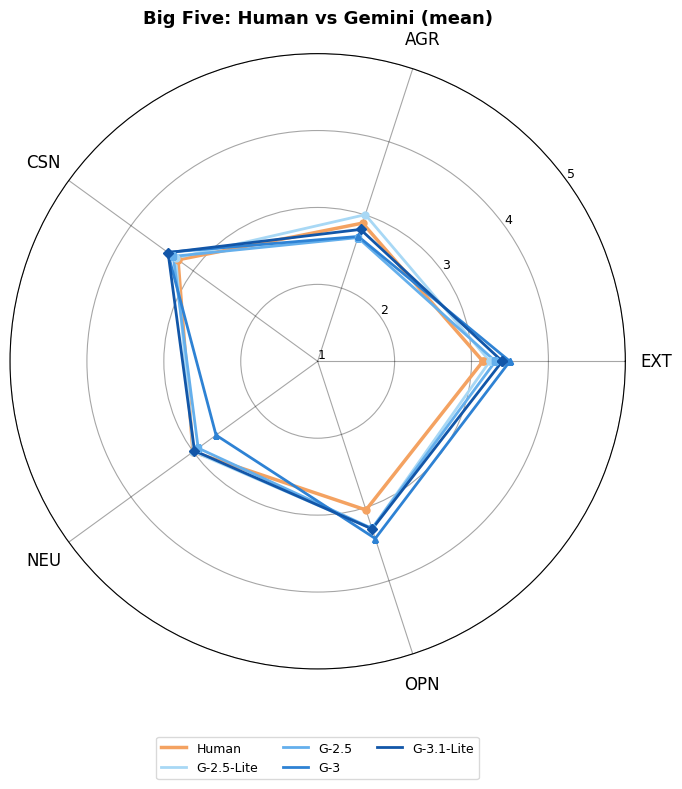

In [142]:
# ── Figure 1: with SD bands ───────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
draw_radar(ax, with_bands=False)
ax.set_title('Big Five: Human vs Gemini (mean)',
             fontsize=13, fontweight='bold', pad=22)
fig.tight_layout()
fig.savefig(os.path.join(output_dir, f'radar.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# Analsis Table 3: Item-Level Agreement

In [113]:
item_cols = [f'item_{i}' for i in range(1, 51)]
human_items = df_all[df_all['source'] == 'Human'][item_cols]
human_item_means = human_items.mean().values

rows_item = []
for llm in llm_list:
    llm_items      = df_all[df_all['source'] == llm][item_cols]
    llm_item_means = llm_items.mean().values

    correlation = np.corrcoef(human_item_means, llm_item_means)[0, 1]
    mad         = np.mean(np.abs(llm_item_means - human_item_means))

    sig_count      = 0
    cohen_d_values = []
    for col in item_cols:
        h_vals = human_items[col].values
        l_vals = llm_items[col].values
        _, p_val = stats.ttest_ind(l_vals, h_vals)
        if p_val < 0.05:
            sig_count += 1
        cohen_d_values.append(abs(cohen_d(l_vals, h_vals)))

    rows_item.append({
        'Model':            llm,
        'Correlation with human itemmeans (r)':                round(correlation, 3),
        'Mean absolute difference in item means':              round(mad, 3),
        'Items with significant mean difference':        f"{sig_count}/50",
        'Average Cohen\'s d across items':      round(np.mean(cohen_d_values), 3),
    })

df_table3 = pd.DataFrame(rows_item).set_index('Model')
df_table3.index = df_table3.index.map(MODEL_LABELS)
df_table3.to_csv(output_dir / 'table3_item_agreement.csv')
df_table3

,Correlation with human itemmeans (r),Mean absolute difference in item means,Items with significant mean difference,Average Cohen's d across items
Model,,,,
G-2.5-Lite,0.763,0.361,35/50,0.306
G-2.5,0.857,0.721,46/50,0.638
G-3,0.735,1.005,48/50,0.885
G-3.1-Lite,0.767,0.573,48/50,0.489


In [ ]:
# def item_level_agreement(df: pd.DataFrame,
#                          ref_group: str = "Human",
#                          comp_group: str = "LLM") -> dict:
#     """Compute item-level agreement metrics"""
#     item_cols = [f'item_{i}' for i in range(1, 51)]

#     human_means = df[df['source'] == ref_group][item_cols].mean().values
#     llm_means = df[df['source'] == comp_group][item_cols].mean().values

#     correlation = np.corrcoef(human_means, llm_means)[0, 1]
#     mad = np.mean(np.abs(llm_means - human_means))

#     sig_count = 0
#     cohen_d_values = []
#     for item_col in item_cols:
#         human_vals = df[df['source'] == ref_group][item_col].values
#         llm_vals = df[df['source'] == comp_group][item_col].values
#         _, p_val = stats.ttest_ind(llm_vals, human_vals)
#         if p_val < 0.05:
#             sig_count += 1
#         d = cohen_d(llm_vals, human_vals)
#         cohen_d_values.append(abs(d))

#     return {
#         'Model': comp_group,
#         'Correlation': correlation,
#         'Mean_Abs_Diff': mad,
#         'Significant_Items': f"{sig_count}/50",
#         'Avg_Cohens_d': np.mean(cohen_d_values)
#     }

# Analysis Table 4: Distributional Similarity (Trait-Level)

In [138]:
rows = []
for trait_name, items in TRAIT_STRUCTURE.items():
    item_cols = [f'item_{i}' for i in items]
    human_df = df_all[df_all['source'] == 'Human']

    for llm in llm_list:
        llm_df = df_all[df_all['source'] == llm]
        wasserstein_dists, js_divs, chi_sq_stats = [], [], []
        max_chi_item, max_chi_val = "", 0

        for item_col in item_cols:
            human_vals = human_df[item_col].dropna().values
            llm_vals = llm_df[item_col].dropna().values

            wd = wasserstein_distance(human_vals, llm_vals)
            wasserstein_dists.append(wd)

            human_dist = np.bincount(human_vals.astype(int), minlength=6)[1:6]
            llm_dist = np.bincount(llm_vals.astype(int), minlength=6)[1:6]
            human_dist = human_dist / human_dist.sum()
            llm_dist = llm_dist / llm_dist.sum()
            js = jensen_shannon_divergence(human_dist, llm_dist)
            js_divs.append(js)

            contingency = pd.crosstab(
                pd.Series(np.concatenate([['Human'] * len(human_vals), ['LLM'] * len(llm_vals)])),
                pd.Series(np.concatenate([human_vals, llm_vals]))
            )
            chi2, _, _, _ = stats.chi2_contingency(contingency)
            chi_sq_stats.append(chi2)
            if chi2 > max_chi_val:
                max_chi_val = chi2
                max_chi_item = item_col

        rows.append({
            'Trait':                 trait_name,
            'Model':                 llm,
            'Avg_Wasserstein':       np.mean(wasserstein_dists),
            'Avg_JS_divergence':     np.mean(js_divs),
            'Avg_Chi_sq':            np.mean(chi_sq_stats),
            'Highest_mismatch_item': max_chi_item,
        })

df_table4 = pd.DataFrame(rows)
df_table4.head(20)

,Trait,Model,Avg_Wasserstein,Avg_JS_divergence,Avg_Chi_sq,Highest_mismatch_item
0,Extraversion,gemini-2.5-flash-lite,0.650833,0.179147,539.001490,item_1
1,Extraversion,gemini-2.5-flash,0.732293,0.112076,299.324721,item_21
2,Extraversion,gemini-3-flash-preview,1.081795,0.197947,705.079409,item_31
3,Extraversion,gemini-3.1-flash-lite-preview,0.898132,0.262246,868.707960,item_36
4,Agreeableness,gemini-2.5-flash-lite,0.640269,0.169692,562.928308,item_2
5,Agreeableness,gemini-2.5-flash,0.762034,0.138340,450.078090,item_27
6,Agreeableness,gemini-3-flash-preview,1.070531,0.223582,804.039070,item_17
7,Agreeableness,gemini-3.1-flash-lite-preview,0.817065,0.248858,931.486939,item_7
8,Conscientiousness,gemini-2.5-flash-lite,0.660378,0.167616,571.695489,item_13
9,Conscientiousness,gemini-2.5-flash,0.884577,0.162612,628.489118,item_38


In [ ]:
def distributional_similarity(df: pd.DataFrame,
                              ref_group: str = "Human",
                              comp_group: str = "LLM") -> pd.DataFrame:
    """Compute distributional similarity metrics for each trait"""
    results = []
    for trait_name, items in TRAIT_STRUCTURE.items():
        item_cols = [f'item_{i}' for i in items]
        wasserstein_dists, js_divs, chi_sq_stats = [], [], []
        max_chi_item, max_chi_val = "", 0

        for item_col in item_cols:
            human_vals = df[df['source'] == ref_group][item_col].dropna().values
            llm_vals = df[df['source'] == comp_group][item_col].dropna().values

            wd = wasserstein_distance(human_vals, llm_vals)
            wasserstein_dists.append(wd)

            human_dist = np.bincount(human_vals.astype(int), minlength=6)[1:6]
            llm_dist = np.bincount(llm_vals.astype(int), minlength=6)[1:6]
            human_dist = human_dist / human_dist.sum()
            llm_dist = llm_dist / llm_dist.sum()
            js = jensen_shannon_divergence(human_dist, llm_dist)
            js_divs.append(js)

            contingency = pd.crosstab(
                pd.Series(np.concatenate([['Human']*len(human_vals), ['LLM']*len(llm_vals)])),
                pd.Series(np.concatenate([human_vals, llm_vals]))
            )
            chi2, _, _, _ = stats.chi2_contingency(contingency)
            chi_sq_stats.append(chi2)
            if chi2 > max_chi_val:
                max_chi_val = chi2
                max_chi_item = item_col

        results.append({
            'Trait': trait_name,
            'Avg_Wasserstein': np.mean(wasserstein_dists),
            'Avg_JS_divergence': np.mean(js_divs),
            'Avg_Chi_sq': np.mean(chi_sq_stats),
            'Highest_mismatch_item': max_chi_item
        })
    return pd.DataFrame(results)

## Table 4B: Item-Level Distributional Analysis

*(Uncomment to enable)*

In [ ]:
def item_distributional_analysis(df: pd.DataFrame,
                                 ref_group: str = "Human",
                                 comp_group: str = "LLM") -> pd.DataFrame:
    """Compute distributional similarity metrics for each individual item"""
    results = []
    for item_num in range(1, 51):
        item_col = f'item_{item_num}'
        trait = next((t for t, items in TRAIT_STRUCTURE.items() if item_num in items), None)

        human_vals = df[df['source'] == ref_group][item_col].dropna().values
        llm_vals = df[df['source'] == comp_group][item_col].dropna().values

        wd = wasserstein_distance(human_vals, llm_vals)

        human_dist = np.bincount(human_vals.astype(int), minlength=6)[1:6]
        llm_dist = np.bincount(llm_vals.astype(int), minlength=6)[1:6]
        human_dist = human_dist / human_dist.sum()
        llm_dist = llm_dist / llm_dist.sum()
        js = jensen_shannon_divergence(human_dist, llm_dist)

        contingency = pd.crosstab(
            pd.Series(np.concatenate([['Human']*len(human_vals), ['LLM']*len(llm_vals)])),
            pd.Series(np.concatenate([human_vals, llm_vals]))
        )
        chi2, _, _, _ = stats.chi2_contingency(contingency)

        results.append({
            'Item': item_num,
            'Trait': trait,
            'Wasserstein_Distance': wd,
            'JS_Divergence': js,
            'Chi_Square': chi2
        })
    return pd.DataFrame(results)

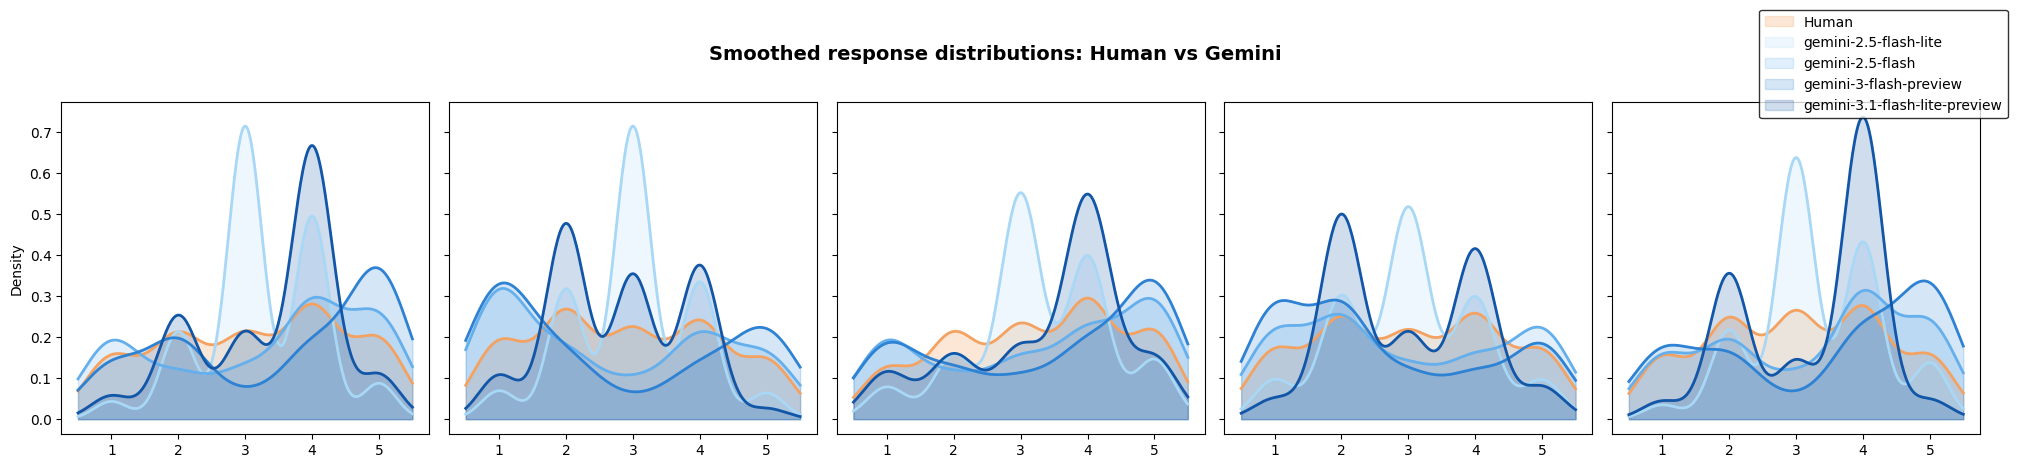

In [ ]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharey=True)
x_grid = np.linspace(0.5, 5.5, 300)

for ax, trait in zip(axes, traits):
    cols = [f'item_{i}' for i in TRAIT_STRUCTURE[trait]]
    human_df = df_all[df_all['source'] == 'Human']

    h_vals = pd.to_numeric(human_df[cols].values.ravel(), errors='coerce')
    h_vals = h_vals[~np.isnan(h_vals)]
    h_kde = gaussian_kde(h_vals, bw_method=0.3)(x_grid)

    ax.fill_between(x_grid, h_kde, color=COLORS['Human'], alpha=0.25, label='Human')
    ax.plot(x_grid, h_kde, color=COLORS['Human'], linewidth=2)

    for llm in llm_list:
        llm_df = df_all[df_all['source'] == llm]

        l_vals = pd.to_numeric(llm_df[cols].values.ravel(), errors='coerce')
        l_vals = l_vals[~np.isnan(l_vals)]
        l_kde = gaussian_kde(l_vals, bw_method=0.3)(x_grid)

        ax.fill_between(x_grid, l_kde, color=COLORS[llm], alpha=0.20, label=llm)
        ax.plot(x_grid, l_kde, color=COLORS[llm], linewidth=2)

axes[0].set_ylabel('Density')

handles, labels = axes[-1].get_legend_handles_labels()
# Deduplicate legend entries (each label appears once per trait panel)
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
fig.legend(seen.values(), seen.keys(),
           loc='upper right', bbox_to_anchor=(1.01, 1.12),
           fontsize=10, framealpha=0.8)

fig.suptitle('Smoothed response distributions: Human vs Gemini',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_dir / 'distributions_kde_gemini.png', dpi=300, bbox_inches='tight')
plt.show()

## Table 5: Structural Comparison

*(Uncomment to enable)*

In [ ]:
def structural_comparison(df: pd.DataFrame, source_label: str) -> dict:
    """Compute structural metrics for one group"""
    source_data = df[df['source'] == source_label]
    item_cols = [f'item_{i}' for i in range(1, 51)]

    cor_matrix = source_data[item_cols].corr()
    mask = np.triu(np.ones_like(cor_matrix), k=1).astype(bool)
    mean_inter_item = cor_matrix.where(mask).stack().mean()

    alphas = {}
    for trait_name, items in TRAIT_STRUCTURE.items():
        item_cols_trait = [f'item_{i}' for i in items]
        alphas[trait_name] = cronbach_alpha(source_data[item_cols_trait])

    return {
        'results': {
            'Source': source_label,
            'Mean_inter_item_cor': mean_inter_item,
            **{f'Alpha_{trait}': val for trait, val in alphas.items()}
        },
        'cor_matrix': cor_matrix
    }

def compute_matrix_similarity(human_cor: pd.DataFrame, llm_cor: pd.DataFrame) -> float:
    """Compute correlation between correlation matrices"""
    mask = np.triu(np.ones_like(human_cor), k=1).astype(bool)
    human_lower = human_cor.where(mask).stack().values
    llm_lower = llm_cor.where(mask).stack().values
    return np.corrcoef(human_lower, llm_lower)[0, 1]

## Table 6: Classification / Separability

In [ ]:
def classification_analysis(trait_scores: pd.DataFrame,
                            ref_group: str = "Human",
                            comp_group: str = "GPT-4.1") -> dict:
    """Analyze separability of human and LLM responses using classification"""
    traits = list(TRAIT_STRUCTURE.keys())
    class_data = trait_scores[trait_scores['source'].isin([ref_group, comp_group])].copy()
    class_data['group'] = (class_data['source'] == comp_group).astype(int)

    X = class_data[traits].values
    y = class_data['group'].values

    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)

    y_pred_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)

    auc = roc_auc_score(y, y_pred_proba)
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    human_traits = class_data[class_data['group'] == 0][traits].values
    llm_traits = class_data[class_data['group'] == 1][traits].values
    pooled_data = np.vstack([human_traits, llm_traits])
    cov_matrix = np.cov(pooled_data.T)
    mean_human = human_traits.mean(axis=0)
    mean_llm = llm_traits.mean(axis=0)
    mahal_dist = mahalanobis_distance(mean_llm, mean_human, cov_matrix)

    return {
        'Comparison': f"{ref_group} vs {comp_group}",
        'AUC': auc,
        'Accuracy': accuracy,
        'F1_score': f1,
        'Mean_Mahalanobis': mahal_dist
    }

## Table 7: Response Style Metrics

*(Uncomment to enable)*

In [ ]:
def response_style_metrics(df: pd.DataFrame, source_label: str) -> dict:
    """Compute response style metrics for one group"""
    source_data = df[df['source'] == source_label]
    item_cols = [f'item_{i}' for i in range(1, 51)]

    acquiescence = source_data[item_cols].mean().mean() - 3

    extreme_count = ((source_data[item_cols] == 1) | (source_data[item_cols] == 5)).sum().sum()
    total_responses = source_data[item_cols].notna().sum().sum()
    extreme_rate = extreme_count / total_responses

    midpoint_count = (source_data[item_cols] == 3).sum().sum()
    midpoint_rate = midpoint_count / total_responses

    inconsistencies = []
    for trait_name, items in TRAIT_STRUCTURE.items():
        regular_items = [i for i in items if i not in REVERSE_ITEMS]
        reverse_items_trait = [i for i in items if i in REVERSE_ITEMS]
        if len(regular_items) > 0 and len(reverse_items_trait) > 0:
            regular_cols = [f'item_{i}' for i in regular_items]
            reverse_cols = [f'item_{i}' for i in reverse_items_trait]
            reg_means = source_data[regular_cols].mean(axis=1)
            rev_means = source_data[reverse_cols].mean(axis=1)
            inconsistencies.extend(np.abs(reg_means - rev_means).dropna().values)
    reverse_inconsistency = np.mean(inconsistencies) if inconsistencies else np.nan

    sd_items = TRAIT_STRUCTURE['Agreeableness'] + TRAIT_STRUCTURE['Conscientiousness']
    sd_cols = [f'item_{i}' for i in sd_items]
    sd_score = source_data[sd_cols].mean(axis=1)
    overall_score = source_data[item_cols].mean(axis=1)
    sd_loading = sd_score.corr(overall_score)

    return {
        'Source': source_label,
        'Acquiescence_index': acquiescence,
        'Extreme_response_rate': extreme_rate,
        'Midpoint_response_rate': midpoint_rate,
        'Reverse_key_inconsistency': reverse_inconsistency,
        'Social_desirability_loading': sd_loading
    }

## Table 8: Item-by-Item Comparison

*(Uncomment to enable)*

In [ ]:
def item_by_item_comparison(df: pd.DataFrame,
                            ref_group: str = "Human",
                            comp_group: str = "GPT-4.1",
                            item_names: List[str] = None) -> pd.DataFrame:
    """Detailed item-by-item comparison"""
    results = []
    for item_num in range(1, 51):
        item_col = f'item_{item_num}'
        human_vals = df[df['source'] == ref_group][item_col].dropna().values
        llm_vals = df[df['source'] == comp_group][item_col].dropna().values
        trait = next((t[0] for t, items in TRAIT_STRUCTURE.items() if item_num in items), None)
        t_stat, p_val = stats.ttest_ind(llm_vals, human_vals)
        d = cohen_d(llm_vals, human_vals)
        results.append({
            'Item_No': item_num,
            'Item_stem': item_names[item_num-1] if item_names else f"Item {item_num}",
            'Trait': trait,
            'Human_Mean': human_vals.mean(),
            'LLM_Mean': llm_vals.mean(),
            'Mean_Diff': llm_vals.mean() - human_vals.mean(),
            't_statistic': t_stat,
            'p_value': p_val,
            'Cohens_d': d
        })
    return pd.DataFrame(results)

## Main Analysis Functions

In [ ]:
def run_multi_model_analysis(human_filepath: str, model_paths: Dict[str, str], output_dir: str = "results"):
    """
    Run complete analysis comparing human responses against multiple LLM models.

    Args:
        human_filepath: Path to human responses CSV
        model_paths: Dictionary of {model_name: path_to_csv}
        output_dir: Directory to save results
    """
    os.makedirs(output_dir, exist_ok=True)

    print("Loading and preprocessing data...")
    df = load_multiple_models(human_filepath, model_paths)
    trait_scores = compute_trait_scores(df)

    print(f"\nLoaded {len(df)} total responses")
    print(f"  - Human: {len(df[df['source'] == 'Human'])}")
    for model_name in model_paths.keys():
        count = len(df[df['source'] == model_name])
        print(f"  - {model_name}: {count}")

    all_results = {
        'df': df,
        'trait_scores': trait_scores,
        'models': {},
        'tables': {}
    }

    # -------------------------------------------------------------------------
    # TABLE 2: Trait-level mean comparisons  (uncomment to enable)
    # -------------------------------------------------------------------------
    # print("\nComputing Table 2: Trait-level mean comparisons")
    # table2_results = []
    # for model_name in model_paths.keys():
    #     traits = list(TRAIT_STRUCTURE.keys())
    #     for trait in traits:
    #         human_vals = trait_scores[trait_scores['source'] == 'Human'][trait].values
    #         model_vals = trait_scores[trait_scores['source'] == model_name][trait].values
    #         t_stat, p_val = stats.ttest_ind(model_vals, human_vals)
    #         d = cohen_d(model_vals, human_vals)
    #         table2_results.append({
    #             'Model': model_name, 'Trait': trait,
    #             'Human_Mean': human_vals.mean(), 'Human_SD': human_vals.std(),
    #             'Model_Mean': model_vals.mean(), 'Model_SD': model_vals.std(),
    #             'Mean_Diff': model_vals.mean() - human_vals.mean(),
    #             't_statistic': t_stat, 'p_value': p_val, 'Cohens_d': d
    #         })
    # table2 = pd.DataFrame(table2_results)
    # table2.to_csv(f"{output_dir}/table2_trait_comparison.csv", index=False)
    # all_results['tables']['table2'] = table2

    # -------------------------------------------------------------------------
    # TABLE 3: Item-level agreement  (uncomment to enable)
    # -------------------------------------------------------------------------
    # print("\nComputing Table 3: Item-level agreement")
    # table3_results = [item_level_agreement(df, "Human", m) for m in model_paths.keys()]
    # table3 = pd.DataFrame(table3_results)
    # table3.to_csv(f"{output_dir}/table3_item_agreement.csv", index=False)
    # all_results['tables']['table3'] = table3

    # -------------------------------------------------------------------------
    # TABLE 4: Distributional similarity (trait-level)  (uncomment to enable)
    # -------------------------------------------------------------------------
    # print("\nComputing Table 4: Distributional similarity")
    # table4_all = []
    # for model_name in model_paths.keys():
    #     t4 = distributional_similarity(df, "Human", model_name)
    #     t4['Model'] = model_name
    #     table4_all.append(t4)
    # table4 = pd.concat(table4_all, ignore_index=True)
    # table4.to_csv(f"{output_dir}/table4_distributional_similarity.csv", index=False)
    # all_results['tables']['table4'] = table4

    # -------------------------------------------------------------------------
    # TABLE 4B: Item-level distributional analysis  (uncomment to enable)
    # -------------------------------------------------------------------------
    # print("\nComputing Table 4B: Item-level distributional analysis")
    # table4b_all = []
    # for model_name in model_paths.keys():
    #     t4b = item_distributional_analysis(df, "Human", model_name)
    #     t4b['Model'] = model_name
    #     table4b_all.append(t4b)
    # table4b = pd.concat(table4b_all, ignore_index=True)
    # table4b.to_csv(f"{output_dir}/table4b_item_distributions.csv", index=False)
    # all_results['tables']['table4b'] = table4b

    # -------------------------------------------------------------------------
    # TABLE 5: Structural comparison  (uncomment to enable)
    # -------------------------------------------------------------------------
    # print("\nComputing Table 5: Structural comparison")
    # struct_human = structural_comparison(df, "Human")
    # struct_results = [{**struct_human['results'], 'Matrix_correlation': np.nan, 'Factor_congruence': np.nan}]
    # for model_name in model_paths.keys():
    #     struct_model = structural_comparison(df, model_name)
    #     matrix_cor = compute_matrix_similarity(struct_human['cor_matrix'], struct_model['cor_matrix'])
    #     struct_results.append({**struct_model['results'], 'Matrix_correlation': matrix_cor, 'Factor_congruence': np.nan})
    # table5 = pd.DataFrame(struct_results)
    # table5.to_csv(f"{output_dir}/table5_structural_comparison.csv", index=False)
    # all_results['tables']['table5'] = table5

    # -------------------------------------------------------------------------
    # TABLE 6: Classification / Separability
    # -------------------------------------------------------------------------
    print("\n" + "="*80)
    print("Computing Table 6: Classification/Separability")
    print("="*80)
    table6_results = []
    for model_name in model_paths.keys():
        print(f"  - {model_name}")
        result = classification_analysis(trait_scores, "Human", model_name)
        table6_results.append(result)

    table6 = pd.DataFrame(table6_results)
    table6.to_csv(f"{output_dir}/table6_classification.csv", index=False)
    print(f"Saved: {output_dir}/table6_classification.csv")
    all_results['tables']['table6'] = table6

    print(f"\n{'='*80}")
    print(f"Analysis complete! All results saved to {output_dir}/")
    print(f"{'='*80}")

    return all_results

## Run Analysis

Configure model paths below and run the analysis.

In [ ]:
# ============================================================================
# Configure model paths here
# ============================================================================
model_paths = {
    'LLM': 'data/processed_llm.csv',
    # 'GPT-4': 'data/gpt4_responses.csv',
    # 'Claude': 'data/claude_responses.csv',
    # 'Deepseek': 'data/deepseek_responses.csv',
}

results = run_multi_model_analysis(
    human_filepath='data/processed_human.csv',
    model_paths=model_paths,
    output_dir='results'
)

## Inspect Results

In [ ]:
# Table 6: Classification / Separability
results['tables']['table6']

In [ ]:
# Trait score distributions
trait_scores = results['trait_scores']
traits = list(TRAIT_STRUCTURE.keys())

fig, axes = plt.subplots(1, len(traits), figsize=(18, 4))
for ax, trait in zip(axes, traits):
    for source, grp in trait_scores.groupby('source'):
        grp[trait].plot.kde(ax=ax, label=source)
    ax.set_title(trait)
    ax.legend()
plt.suptitle('Trait Score Distributions: Human vs LLM', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()